Project name:Customer Segmentation and Predictive Modeling for
Marketing Analytics

In [ ]:

# 1. Import Necessary Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings

# Settings & Style
warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')


# 2. Data Loading & Initial Observation

# Load the Mall_Customers.csv file
data = pd.read_csv("/content/sample_data/Mall_Customers.csv")




In [ ]:
print("--- Dataset Snapshot ---")
print(data.head())


--- Dataset Snapshot ---
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


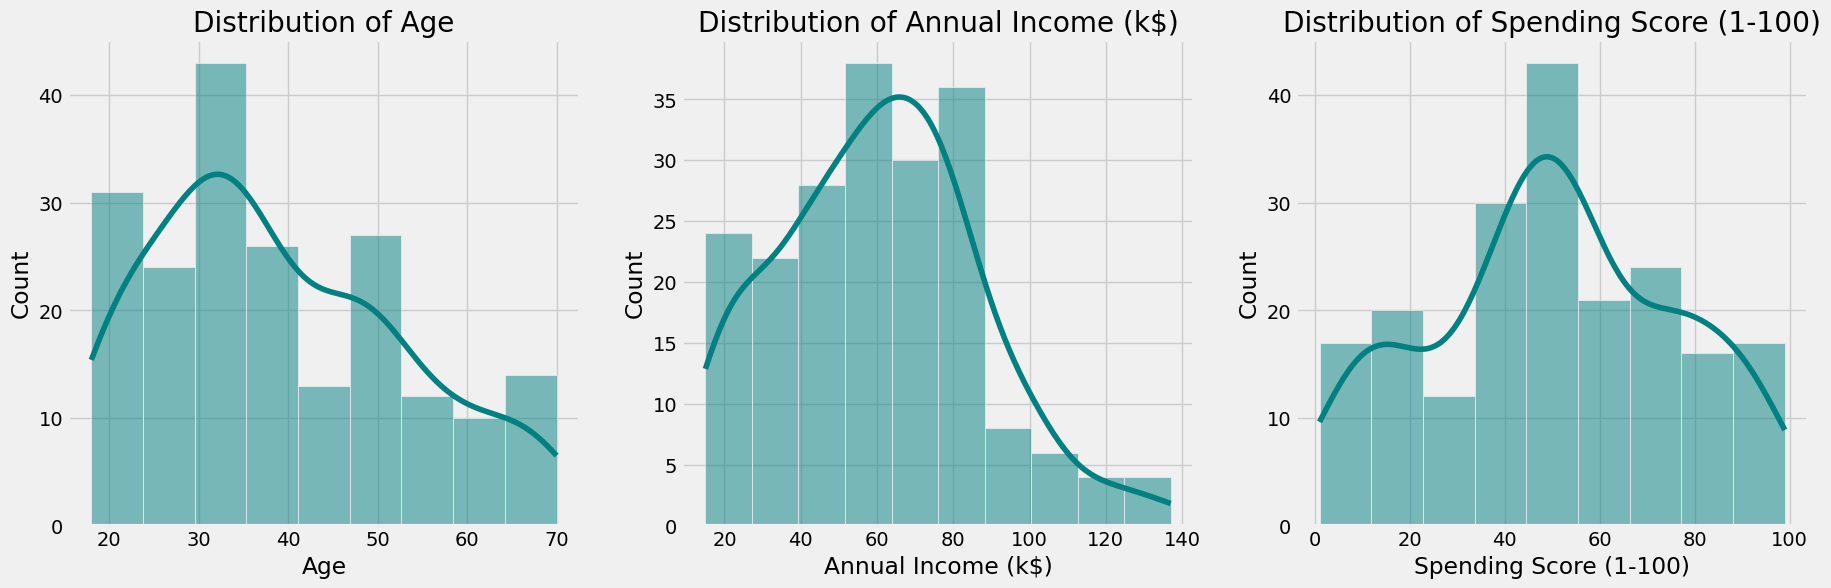

In [ ]:
# Feature Distribution (Age, Income, Spending Score)
plt.figure(figsize = (20, 6))
features_to_plot = ['Age' , 'Annual Income (k$)' , 'Spending Score (1-100)']
for i, col in enumerate(features_to_plot):
    plt.subplot(1 , 3 , i+1)
    sns.histplot(data[col], kde=True, color='teal')
    plt.title(f'Distribution of {col}')
plt.show()

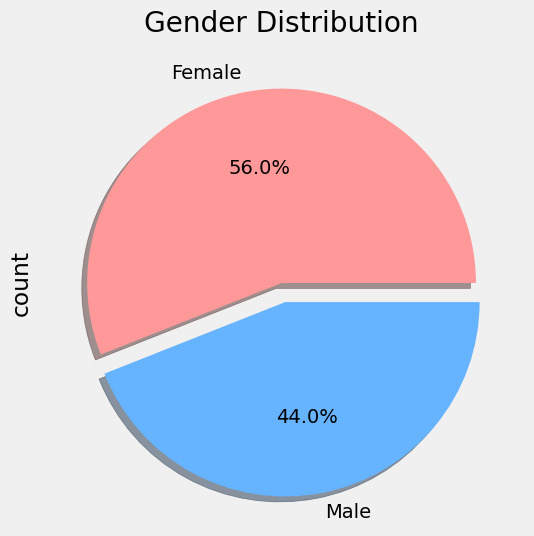

In [ ]:

# 3. Exploratory Data Analysis (EDA)
# Gender Distribution (Pie Chart)
plt.figure(figsize=(8,6))
data['Gender'].value_counts().plot.pie(explode=[0,0.1], autopct='%1.1f%%', shadow=True, colors=['#ff9999','#66b3ff'])
plt.title("Gender Distribution")
plt.show()





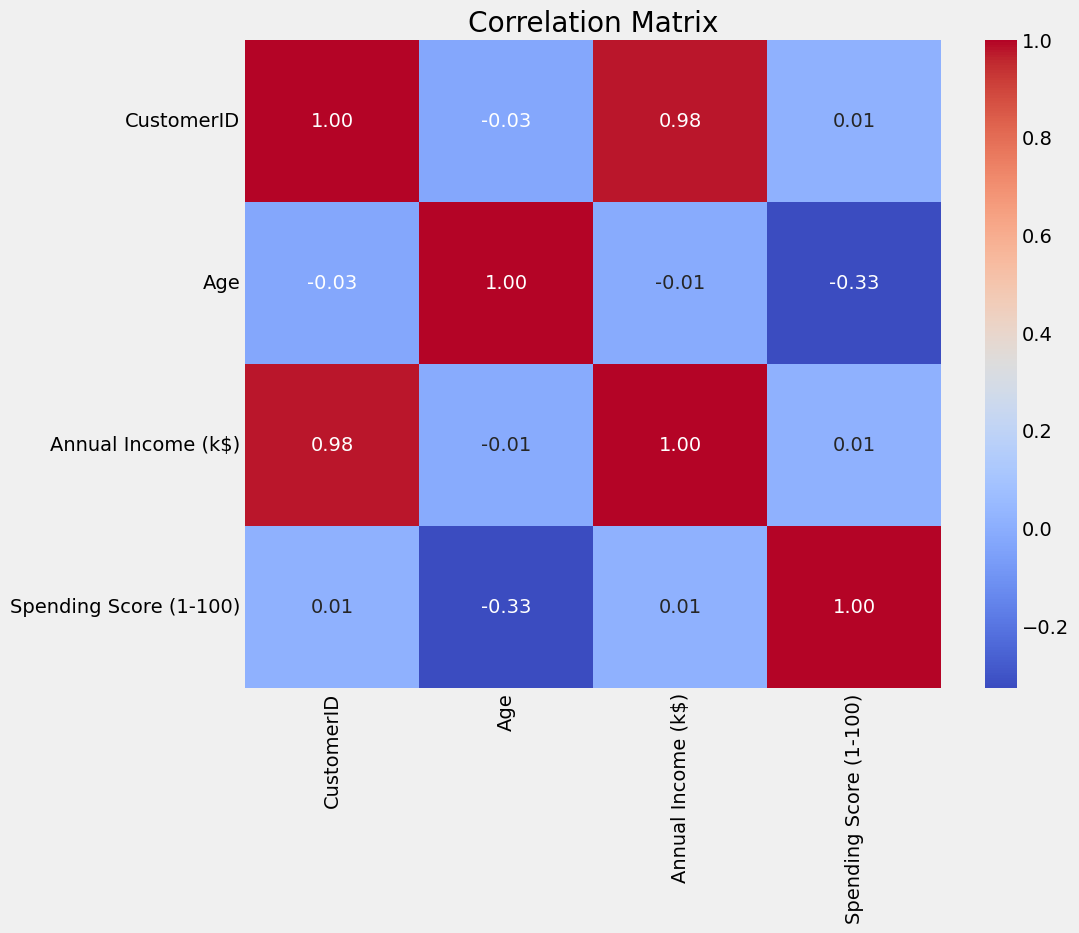

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# 4. Data Pre-processing & Feature Scaling
# Selecting main 3 features for clustering
X_features = data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Using StandardScaler to prevent high values (Income) from biasing the model
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# 5. Model Validation (Optimal K Selection)
wcss = []
silhouette_avg = []

for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(X_scaled, cluster_labels))


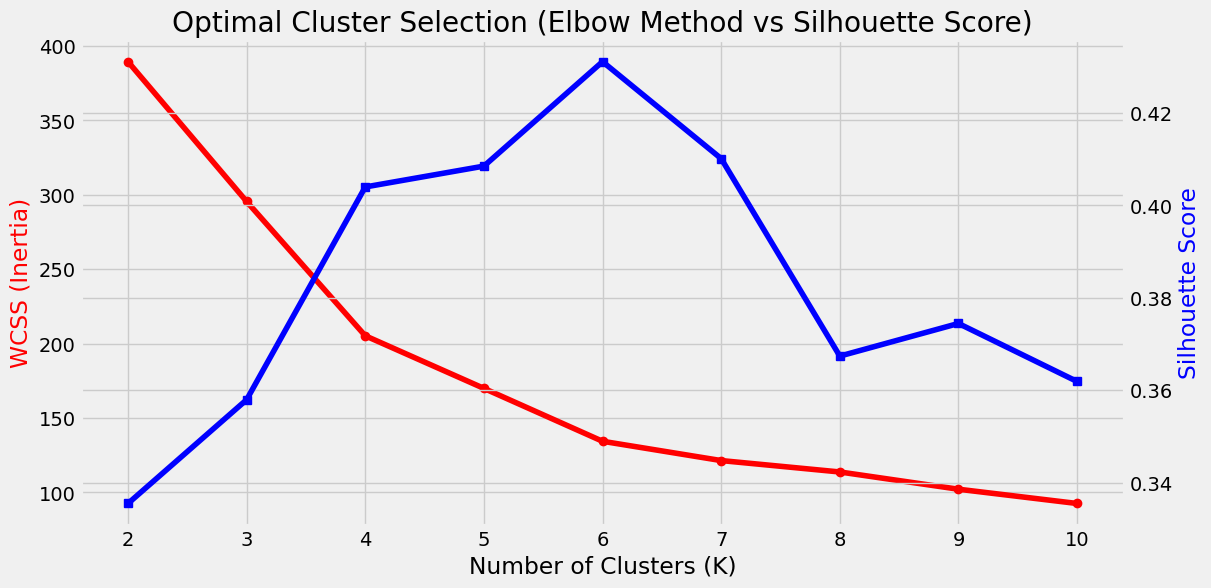

In [ ]:

# Visualization of Elbow Method vs Silhouette Score
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(range(2, 11), wcss, color='red', marker='o', label='WCSS (Elbow)')
ax1.set_ylabel('WCSS (Inertia)', color='red')
ax1.set_xlabel('Number of Clusters (K)')

ax2 = ax1.twinx()
ax2.plot(range(2, 11), silhouette_avg, color='blue', marker='s', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='blue')

plt.title('Optimal Cluster Selection (Elbow Method vs Silhouette Score)')
plt.show()


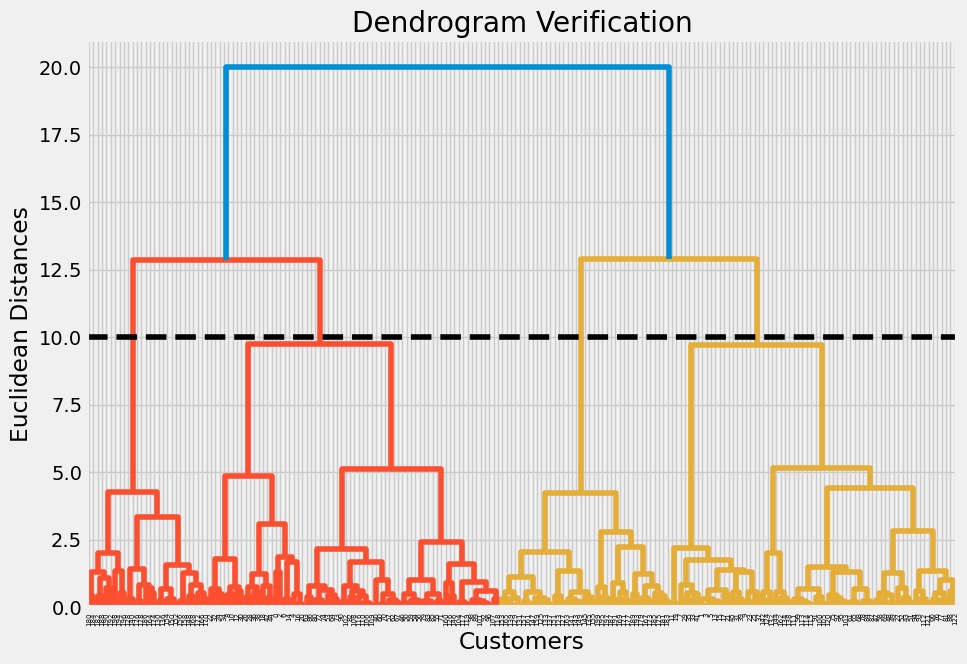

In [ ]:

import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

#dendrogram
plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))

plt.title('Dendrogram Verification')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distances')
plt.axhline(y=10, color='black', linestyle='--') #
plt.show()

In [ ]:


# 6. Final K-Means Model Training (K=5)

kmeans_final = KMeans(n_clusters=5, init='k-means++', random_state=42)
data['Cluster'] = kmeans_final.fit_predict(X_scaled)



In [ ]:
# 7. Profiling & Marketing Strategy (Logical Mapping)

print("\n--- Summary of Customer Segments (Averages) ---")
summary = data.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
print(summary)

def predict_personalized_strategy(age, income, score):
    # Creating input dataframe to avoid warnings
    input_data = pd.DataFrame([[age, income, score]],
                            columns=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'])

    scaled_input = scaler.transform(input_data)
    cluster_id = kmeans_final.predict(scaled_input)[0]

    # Dynamic marketing plan based on data averages
    strategies = {
        0: "Target: Stable Seniors (Older, Moderate Spend). Strategy: Health/Reliability focused loyalty rewards.",
        1: "Target: VIP High-Rollers (High Income, High Spend). Strategy: Exclusive Luxury invites & VIP Concierge.",
        2: "Target: Impulsive Youth (Low Income, High Spend). Strategy: Social Media Trends & Flash Sales.",
        3: "Target: Cautious Young Adults (Lower Income/Spend). Strategy: Discount Coupons & Student Offers.",
        4: "Target: High-Income Skeptics (High Income, Low Spend). Strategy: Premium value propositions & trust campaigns."
    }

    return cluster_id, strategies.get(cluster_id, "Unknown Segment")



--- Summary of Customer Segments (Averages) ---
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        55.275862           47.620690               41.706897
1        32.875000           86.100000               81.525000
2        25.769231           26.115385               74.846154
3        26.733333           54.311111               40.911111
4        44.387097           89.774194               18.483871


In [ ]:
#@title Customer Prediction Tool { run: "auto" }
Age = 40 #@param {type:"integer"}
Annual_Income = 100 #@param {type:"integer"}
Spending_Score = 4 #@param {type:"integer"}

cid, advice = predict_personalized_strategy(Age, Annual_Income, Spending_Score)

print("\n" + "="*60)
print("          CUSTOMER SEGMENTATION RESULT          ")
print("="*60)
print(f" CUSTOMER PROFILE:")
print(f"   - Age: {Age} | Income: ${Annual_Income}k | Score: {Spending_Score}")
print("-" * 60)
print(f" ANALYSIS:")
print(f"   - Assigned Cluster: [ Cluster {cid} ]")
print(f"   - Strategy: {advice}")
print("="*60)


          CUSTOMER SEGMENTATION RESULT          
 CUSTOMER PROFILE:
   - Age: 40 | Income: $100k | Score: 4
------------------------------------------------------------
 ANALYSIS:
   - Assigned Cluster: [ Cluster 4 ]
   - Strategy: Target: High-Income Skeptics (High Income, Low Spend). Strategy: Premium value propositions & trust campaigns.


In [ ]:
# Interactive 3D Visualization
fig = px.scatter_3d(data, x='Age', y='Annual Income (k$)', z='Spending Score (1-100)',
                    color='Cluster', title='Final Customer Segmentation Map',
                    template='plotly_dark')
fig.show()